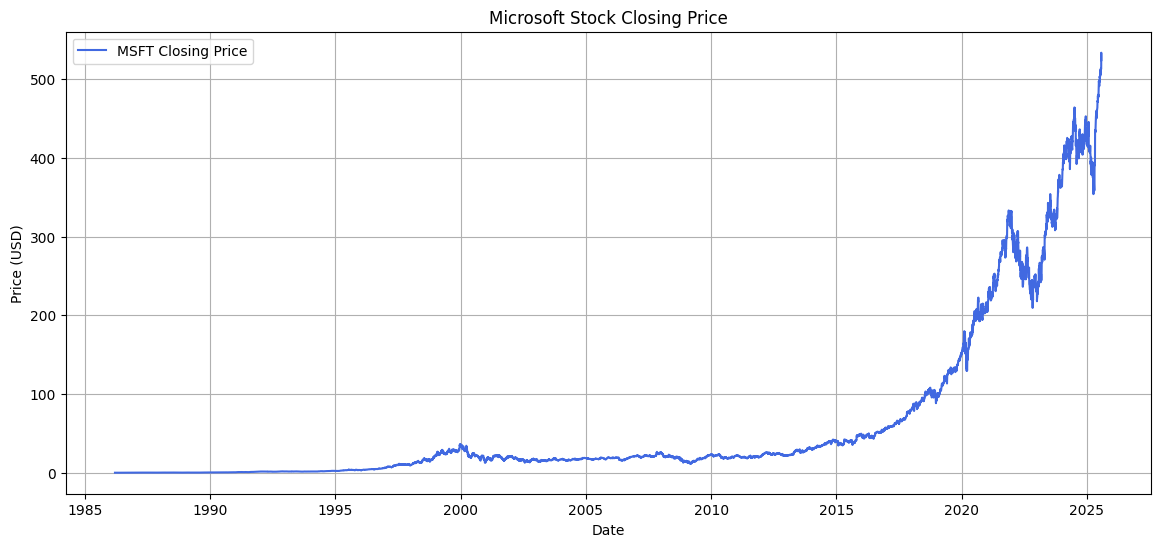

In [1]:
import pandas as pd

df = pd.read_csv("../data/Microsoft_stock_data.csv")

df.head()

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label="MSFT Closing Price", color='royalblue')
plt.title("Microsoft Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
features = ['Close', 'Open', 'High', 'Low', 'Volume']
data = df[features].copy()
data.head()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, index=data.index, columns=features)
scaled_data.head()

In [ ]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Train data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")

In [ ]:
import numpy as np

def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        seq = data.iloc[i:i+window_size].values
        label = data.iloc[i+window_size]['Close']
        X.append(seq)
        y.append(label)
    return np.array(X), np.array(y)

window_size = 30

train_X, train_y = create_sequences(train_data, window_size)
test_X, test_y = create_sequences(test_data, window_size)

print(f"Train X shape: {train_X.shape}")
print(f"Train y shape: {train_y.shape}")
print(f"Test X shape: {test_X.shape}")
print(f"Test y shape: {test_y.shape}")

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y, dtype=torch.float32)

test_X_tensor = torch.tensor(test_X, dtype=torch.float32)
test_y_tensor = torch.tensor(test_y, dtype=torch.float32)

batch_size = 32

train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_X_tensor, test_y_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Kullanılan cihaz: cuda
Epoch [10/100], Loss: 0.000031
Epoch [20/100], Loss: 0.000016
Epoch [30/100], Loss: 0.000082
Epoch [40/100], Loss: 0.000015
Epoch [50/100], Loss: 0.000009
Epoch [60/100], Loss: 0.000010
Epoch [70/100], Loss: 0.000029
Epoch [80/100], Loss: 0.000005
Epoch [90/100], Loss: 0.000008
Epoch [100/100], Loss: 0.000012
MAE: 20.5013
RMSE: 31.2975


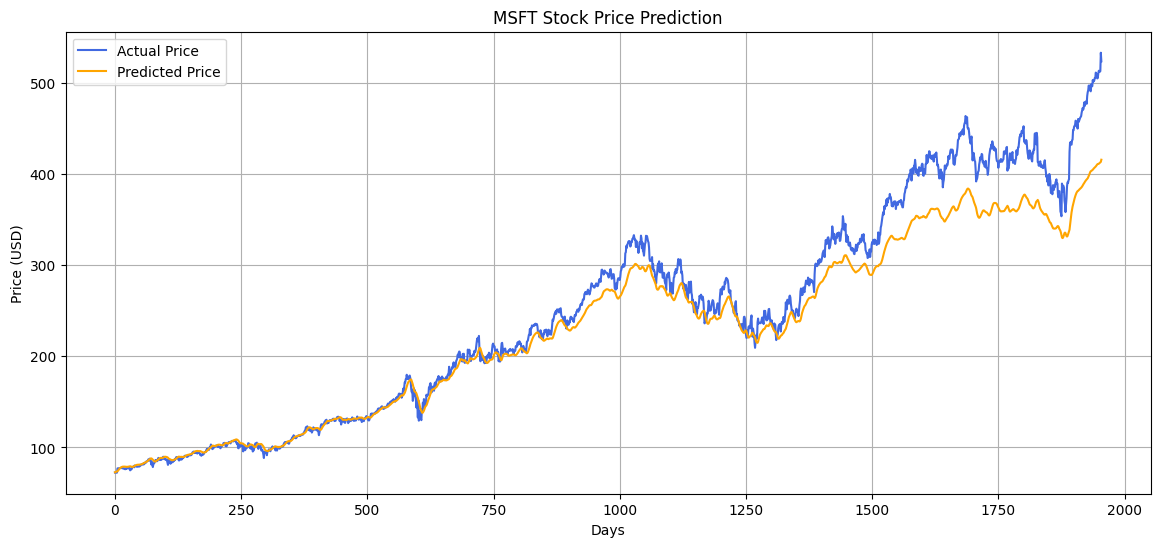

In [6]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error

class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob=0.5):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_prob)
        
        self.dropout = nn.Dropout(dropout_prob)
        
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0,c0))

        out = self.dropout(out)
        
        out = self.fc(out[:, -1, :])
        return out
        
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")

input_size = len(features)
hidden_size = 64
num_layers = 2
output_size = 1
dropout_prob = 0.5

if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout_prob).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)


num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch.unsqueeze(1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.6f}")

model.eval()
predictions = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        predictions.append(output.cpu().numpy())

predictions = np.concatenate(predictions, axis=0)
test_y_np = test_y_tensor.numpy()

dummy_zeros = np.zeros((predictions.shape[0], len(features) - 1))
predictions_expanded = np.concatenate((predictions, dummy_zeros), axis=1)

test_y_np_reshaped = test_y_np.reshape(-1, 1)
test_y_expanded = np.concatenate((test_y_np_reshaped, np.zeros((len(test_y_np_reshaped), len(features) - 1))), axis=1)

predictions_orig_expanded = scaler.inverse_transform(predictions_expanded)
test_y_orig_expanded = scaler.inverse_transform(test_y_expanded)

predictions_orig = predictions_orig_expanded[:, 0]
test_y_orig = test_y_orig_expanded[:, 0]

mae = mean_absolute_error(test_y_orig, predictions_orig)
rmse = np.sqrt(mean_squared_error(test_y_orig, predictions_orig))
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(14,6))
plt.plot(test_y_orig, label="Actual Price", color='royalblue')
plt.plot(predictions_orig, label="Predicted Price", color='orange')
plt.title("MSFT Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.savefig("results.png") 
plt.show()

